# [실습] LangChain Tool Call과 Agent

Tool Calling의 템플릿을 이용하여, 툴을 연속적으로 실행하면 어떨까요?   

최근의 복잡한 에이전트 구조는 다양한 툴을 연결하고 다단 작업을 수행합니다.

# 라이브러리 설정 및 LLM 불러오기

In [ ]:
!pip install setuptools langchain==0.3.27 langchain_community==0.3.27 langgraph==0.6.8 koreanize_matplotlib matplotlib langchain_experimental langchain_google_genai langchain_openai langchain_tavily

In [3]:
import os
from dotenv import load_dotenv
# OPENAI_API_KEY, GOOGLE_API_KEY
load_dotenv(override=True)

True

In [4]:
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.rate_limiters import InMemoryRateLimiter

# Gemini: 무료 API 사용량 존재
# 안정적 서빙을 위해 분당 10개 설정
# 즉, 초당 약 0.167개 요청 (10/60)
# `https://aistudio.google.com/`에서 모델별 사용량 확인

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.167,  # 분당 10개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)


# LLM 초기화
try:
    llm = ChatOpenAI(model='gpt-5-mini', temperature=0.3)
    llm_nonreasoning = ChatOpenAI(model='gpt-4.1-mini', temperature=0.3)
    print("✅ GPT API 사용 가능!")
except:
    print("❌ GPT API 사용 불가- API 키를 확인하세요!")
try:
    llm_gemini = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.7, 
                                rate_limiter=rate_limiter)
    llm_gemini_nonreasoning = ChatGoogleGenerativeAI(model='gemini-2.0-flash', temperature=0.3, 
                                rate_limiter=rate_limiter)
    print("✅ Gemini API 사용 가능!")
except:
    print("❌ Gemini API 사용 불가- API 키를 확인하세요!")

✅ GPT API 사용 가능!
✅ Gemini API 사용 가능!


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

print("필수 모듈 임포트 완료")

필수 모듈 임포트 완료


tavily tool을 준비합니다.

In [7]:
@tool
def tavily_search(query, max_results=5):
    """Tavily API를 통해 검색 결과를 가져옵니다.
주어진 주제에 맞는 적절한 argument 값을 선정하세요.
query: 검색어
max_results : 검색 결과의 수(최소 1, 최대 20, 별도의 요청이 없으면 5로 고정)"""
    tavily_search = TavilySearch(max_results=max_results)

    search_results = tavily_search.invoke(query)['results']

    context =''
    for doc in search_results:
        doc_content = doc.get('content')

        context += 'TITLE: ' + doc.get('title','N/A') + '\nURL:' + doc.get('url')+ '\nContent:'+ doc_content
    return context

이번에는 커스텀 툴을 더 추가해 보겠습니다.

# 커스텀 툴 추가하기   

다양한 외부 API나 기능을 구현하여 툴로 구성할 수 있습니다.   
프롬프트에 포함되는 툴 이름과 설명, 입출력 형식을 이용해 툴의 사용성을 높입니다.

In [23]:
@tool
def multiply(x:int, y:int) -> int:
    "x와 y를 입력받아, x와 y를 곱한 결과를 반환합니다."
    return x*y

@tool
def current_date() -> str:
    "현재 날짜를 %y-%m-%d 형식으로 반환합니다."
    from datetime import datetime
    return f'현재 날짜는 {datetime.now().strftime("%Y-%m-%d")} 입니다!'

print(multiply.invoke({'x':3, 'y':4}))
print(current_date.invoke({}))


12
현재 날짜는 2025-08-24 입니다!


다단 Tool Calling을 수행하는 에이전트 중 가장 대표적인 것은 ReAct 에이전트입니다.
<br><br>

While문과 For문을 이용하여, ReAct 에이전트와 유사한 아래의 함수를 만들어 보겠습니다.

In [13]:
def react_agent(llm, question , tools = [tavily_search]):

    # 툴과 LLM 구성

    tool_list = {x.name: x for x in tools}
    # tavily_search.name = 'tavily_search' 을 이용하면
    # tool_list = {'tavily_search': tavily_search} 와 동일합니다.

    llm_with_tools = llm.bind_tools(tools)


    # 메시지 구성
    messages = [HumanMessage(question)]
    print('Query:', question)


    # LLM에 메시지 전달 (분기)
    tool_msg = llm_with_tools.invoke(question)
    # 1) 툴이 필요없으면: 응답 후 종료
    # 2) 툴이 필요하면: AIMessage (+ Tool Call)
    print('## LLM 호출 ##')
    messages.append(tool_msg)

    if tool_msg.content:
        print('LLM:', tool_msg.content)

    while tool_msg.tool_calls:
        # 툴 호출이 있을 경우: 툴 실행 후 결과를 전달 (반복)

        for tool_call in tool_msg.tool_calls:
            tool_name = tool_call['name']

            print(f"-- {tool_name} 사용 중 --")
            print(tool_call)


            tool_exec = tool_list[tool_name]

            tool_result = tool_exec.invoke(tool_call)
            messages.append(tool_result)
        tool_msg = llm_with_tools.invoke(messages)
        print('## LLM 호출 ##')
        messages.append(tool_msg)

        if tool_msg.content:
            print('LLM:', tool_msg.content)


    result = tool_msg

    return result.content

In [17]:
response = react_agent(llm, "Gemma 3 모델의 장단점 검색해서 알려줘. 매번 툴 요청과 함께, 어떤 툴을 어떻게 실행할 건지 활기차게 말해줘.")
# GPT-5-Mini
print(response)

Query: Gemma 3 모델의 장단점 검색해서 알려줘. 매번 툴 요청과 함께, 어떤 툴을 어떻게 실행할 건지 활기차게 말해줘.
## LLM 호출 ##
LLM: 신나는 톤으로 알려드릴게요 — 지금 Tavily 검색 API를 사용해서 "Gemma 3 모델 장단점" 관련 최신 자료를 한 번에 5개씩 찾아볼게요. 검색어는 한국어와 영어를 섞어 넓게 찾겠습니다. (툴: functions.tavily_search, 파라미터: query="Gemma 3 model 장단점 pros cons", max_results=5)
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': 'Gemma 3 model 장단점 pros cons', 'max_results': 5}, 'id': 'call_vsWpk8rc4YSz3M33JNeNXD4Z', 'type': 'tool_call'}
## LLM 호출 ##
LLM: 와우! 방금 활기차게 Tavily 검색 API를 실행해서("Gemma 3 model 장단점 pros cons"로 검색, 결과 5개 가져옴) 최신 자료들을 쭉 긁어왔어요 — 이제 요점만 깔끔하게 정리해 드릴게요!

요약(장단점)
장점
- 뛰어난 전반적 성능: 여러 벤치마크에서 경쟁력 있는 성능을 보이며, 특히 경량 오픈 모델 제품군 중 상위권에 위치합니다. (참조: Toolify, Bits-Bytes 보고서)
  - 출처: https://www.toolify.ai/ko/ai-news-kr/gemma-3-3461824  
  - 출처: https://bits-bytes-nn.github.io/multimodal-learning/2025/03/25/gemma-3-technical-report.html
- 멀티모달 지원: 텍스트와 이미지 양쪽을 다루는 VLM(비주얼-언어 모델) 기능이 강화되어 이미지 이해·추출·요약 등이 가능해졌습니다. (참조: Google 모델 카드)
  - 출처: https://ai.google

In [16]:
response = react_agent(llm_nonreasoning, "Gemma 3 모델의 장단점 검색해서 알려줘. 매번 툴 요청과 함께, 어떤 툴을 어떻게 실행할 건지 활기차게 말해줘.")
# GPT-5-Mini
print(response)

Query: Gemma 3 모델의 장단점 검색해서 알려줘. 매번 툴 요청과 함께, 어떤 툴을 어떻게 실행할 건지 활기차게 말해줘.
## LLM 호출 ##
LLM: 좋아요! Gemma 3 모델의 장단점을 알아보기 위해 Tavily API를 사용해 검색해볼게요. "Gemma 3 모델 장단점"이라는 키워드로 검색해서 관련된 정보를 최대 5개 정도 가져올 거예요. 바로 실행해볼게요!
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': 'Gemma 3 모델 장단점', 'max_results': 5}, 'id': 'call_KjYmqT7Ldk5kcnNYgtGct1G2', 'type': 'tool_call'}
## LLM 호출 ##
LLM: Gemma 3 모델의 장단점에 대해 활기차게 알려드릴게요!

장점:
1. 대규모 AI 모델과 비교해 상대적으로 작은 규모지만 성능을 극대화했어요. (출처: Naver 프리미엄)
2. 단일 GPU에 최적화되어 있어 저사양 환경에서도 강력한 AI 성능을 발휘해요. (출처: learningflix)
3. 텍스트와 이미지 입력을 모두 처리하는 멀티모달 AI 모델로 다양한 작업 수행 능력이 뛰어나요. (출처: fornewchallenge.tistory)
4. 140개 이상의 언어를 효과적으로 이해하고 처리할 수 있도록 토크나이저가 개선되었어요. (출처: Naver 프리미엄)
5. 모델 병합 기법을 적용해 여러 AI 모델을 조합하여 성능을 한층 끌어올렸어요. (출처: Naver 프리미엄)

단점:
- 고사양 GPU가 아니어도 활용 가능하지만, 12B 이상의 대형 모델은 여전히 고성능 GPU가 필요할 수 있어요. (출처: marcus-story.tistory)
- 아직은 최신 모델이라 생태계와 활용 사례가 더 확장되어야 하는 부분이 있어요. (출처: aikoreacommunity)

요약하면, Gemma 3는 경량화와 멀티모달 기능, 다국어 지원 등 최신 AI 기술을 담아내면서

In [19]:
tools = [tavily_search, multiply, current_date]
question = '오늘 날짜가 어떻게 되니?'
response = react_agent(llm_gemini_nonreasoning, question, tools= tools)
# 2.0 Flash
print(response)

Query: 오늘 날짜가 어떻게 되니?
## LLM 호출 ##
-- current_date 사용 중 --
{'name': 'current_date', 'args': {}, 'id': '2fb7ab67-cb13-4a8c-9880-8a1aec06355b', 'type': 'tool_call'}
## LLM 호출 ##
LLM: 오늘 날짜는 2025년 8월 24일입니다.
오늘 날짜는 2025년 8월 24일입니다.


# Python REPL Tool 추가하기

3개의 툴에 추가로, Python 코드를 실행하는 REPL 툴을 추가해 보겠습니다.

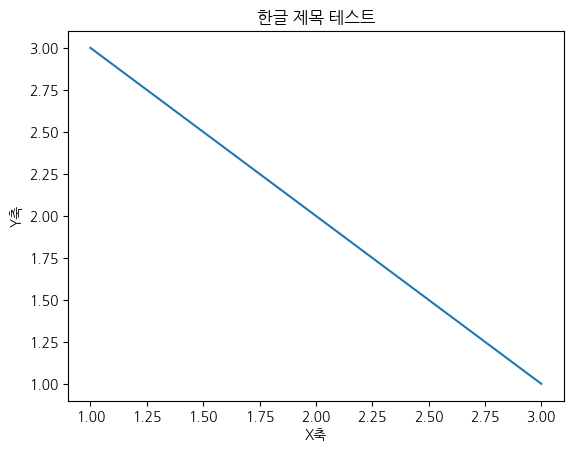

In [20]:
# 한글 출력 테스트
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.plot([1, 2, 3], [3, 2, 1])
plt.title("한글 제목 테스트")
plt.xlabel("X축")
plt.ylabel("Y축")
plt.show()

In [21]:
from langchain_experimental.utilities import PythonREPL
repl = PythonREPL()

PythonREPL은 임의의 코드를 전달하면 결과를 돌려줍니다.

In [22]:
repl.run('print(1)')

Python REPL can execute arbitrary code. Use with caution.


'1\n'

이를 활용하여, 충분한 맥락이 담긴 툴을 구성합니다.

In [24]:
from typing import Annotated

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you MUST print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return result_str

Query: 2024년 프로야구 정규시즌 최종 순위 알려줘. 전체를 그래프로 구성하여 1.png에 저장해.
## LLM 호출 ##
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2024년 프로야구 정규시즌 최종 순위'}, 'id': 'call_MV3cv5iuVqPgraEZkRFAvu3k', 'type': 'tool_call'}
## LLM 호출 ##
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2024년 프로야구 정규시즌 최종 순위 전체'}, 'id': 'call_0vGv3t5G5A4MdcKV6MKLxQkw', 'type': 'tool_call'}
## LLM 호출 ##
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2024년 프로야구 정규시즌 최종 순위 상세', 'max_results': 10}, 'id': 'call_9GX2v98WaNMRxa9ysjNxmKYi', 'type': 'tool_call'}
-- current_date 사용 중 --
{'name': 'current_date', 'args': {}, 'id': 'call_UIIBBqvmpN3kPpLhOCTCJqdW', 'type': 'tool_call'}
## LLM 호출 ##
-- python_repl_tool 사용 중 --
{'name': 'python_repl_tool', 'args': {'code': "import matplotlib.pyplot as plt\nimport numpy as np\n\n# 2024년 프로야구 정규시즌 최종 순위 데이터\nteams = ['KIA 타이거즈', '삼성 라이온즈', 'LG 트윈스', '두산 베어스', 'kt wiz', 'SSG 랜더스', '롯데 자이언츠', 'NC 다이노스']\nwins = [87, 78, 77, 70

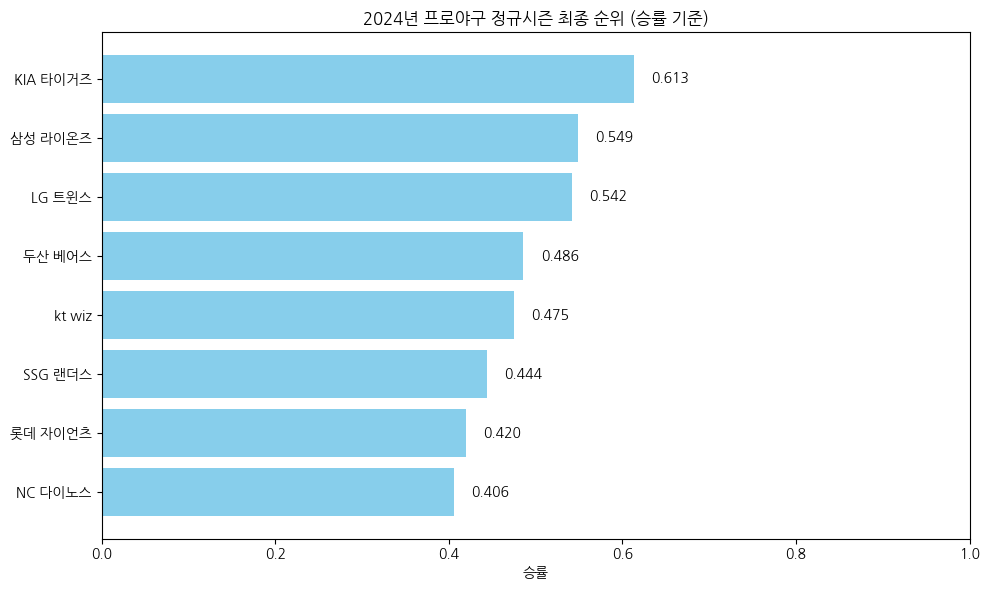

## LLM 호출 ##
LLM: 2024년 프로야구 정규시즌 최종 순위(승률 기준)를 그래프로 구성하여 1.png 파일로 저장했습니다. 주요 팀들의 승률을 가로 막대 그래프로 나타냈습니다. 필요하시면 추가 정보나 다른 형태의 그래프도 만들어 드릴 수 있습니다.


'2024년 프로야구 정규시즌 최종 순위(승률 기준)를 그래프로 구성하여 1.png 파일로 저장했습니다. 주요 팀들의 승률을 가로 막대 그래프로 나타냈습니다. 필요하시면 추가 정보나 다른 형태의 그래프도 만들어 드릴 수 있습니다.'

In [27]:
tools = [tavily_search, current_date, python_repl_tool, multiply]

question = '2024년 프로야구 정규시즌 최종 순위 알려줘. 전체를 그래프로 구성하여 1.png에 저장해.'
react_agent(llm_nonreasoning, question=question, tools=tools)


In [35]:
tools = [tavily_search, current_date, python_repl_tool, multiply]

question = '이번 달에 발매된 주요 한국 래퍼들의 음악 소개해줘. 검색해서 알려줘. 안나오면 나올때까지 다른 검색어를 활용해서 검색해.'
react_agent(llm_gemini, question=question, tools=tools)


Query: 이번 달에 발매된 주요 한국 래퍼들의 음악 소개해줘. 검색해서 알려줘. 안나오면 나올때까지 다른 검색어를 활용해서 검색해.
## LLM 호출 ##
-- current_date 사용 중 --
{'name': 'current_date', 'args': {}, 'id': '936ba441-1f73-4601-bda1-840839d45564', 'type': 'tool_call'}
## LLM 호출 ##
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2025년 8월 한국 래퍼 신곡', 'max_results': 10.0}, 'id': '44d07ed4-d598-4db5-9181-6e0cd3c15f5c', 'type': 'tool_call'}


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 10
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 7
}
].
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 4.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing 

## LLM 호출 ##
LLM: 2025년 8월에 발매된 주요 한국 래퍼들의 신곡 정보는 찾기 어렵습니다. 현재 검색 결과에서는 아이돌 그룹의 앨범 발매 소식이나 해외 래퍼의 내한 공연 정보가 주로 확인됩니다.

혹시 특정 래퍼나 다른 검색어를 알려주시면 다시 찾아보겠습니다.


'2025년 8월에 발매된 주요 한국 래퍼들의 신곡 정보는 찾기 어렵습니다. 현재 검색 결과에서는 아이돌 그룹의 앨범 발매 소식이나 해외 래퍼의 내한 공연 정보가 주로 확인됩니다.\n\n혹시 특정 래퍼나 다른 검색어를 알려주시면 다시 찾아보겠습니다.'

In [31]:
tools = [tavily_search, current_date, python_repl_tool, multiply]

question = '이번 달에 발매된 주요 한국 래퍼들의 음악 소개해줘. 검색은 두번만 하고, 되묻지 말고 끝까지 해.'
react_agent(llm, question=question, tools=tools)


Query: 이번 달에 발매된 주요 한국 래퍼들의 음악 소개해줘. 검색은 두번만 하고, 되묻지 말고 끝까지 해.
## LLM 호출 ##
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2025년 8월 한국 래퍼 신곡 발매', 'max_results': 10}, 'id': 'call_HSIquhAm3gXmLNlQJ3uUXdUD', 'type': 'tool_call'}
-- tavily_search 사용 중 --
{'name': 'tavily_search', 'args': {'query': '2025년 8월 발매 한국 힙합 래퍼 싱글 앨범 목록', 'max_results': 10}, 'id': 'call_j1BUsG4uZ76vuAxLC4s0Lhed', 'type': 'tool_call'}
## LLM 호출 ##
LLM: 요청하신 대로 검색을 두 번만 실행해 확인한 자료로 이번 달(8월) 발매된(또는 발매 공지된) 한국 래퍼 관련 음악을 간단히 정리해드립니다. 검색 결과가 제한적이라 확실히 확인 가능한 항목 위주로 정리했고, 각 항목마다 핵심 포인트(발매일·형식·특징·출처)를 적었습니다.

확인된 항목
- Big Naughty(빅나티) × 이찬혁 — "MUSIC" (협업 싱글·발매 공지)
  - 포인트: 빅나티(한국 래퍼)와 이찬혁의 협업 싱글로 SNS(Instagram)에서 발매 소식/티저가 올라왔습니다. 빅나티의 감성 랩·멜로디 라인이 강조된 협업으로 소개되어 있습니다.
  - 출처: 아티스트 인스타그램 릴스(검색 결과)

- Crush — 새 EP(8월 28일 공개, R&B/힙합 경계)
  - 포인트: Crush는 전통적으로 R&B/힙합 계열 아티스트로 분류됩니다. 8월 28일 새 EP 발표가 SNS/게시글로 확인되며, 랩/리듬 기반 트랙이 포함됩니다.
  - 출처: 검색된 인스타그램/포스트

주의/한계
- 일부 검색 결과(예: "Jealous Type" 표기)는 해외 아티스트(도자캣

'요청하신 대로 검색을 두 번만 실행해 확인한 자료로 이번 달(8월) 발매된(또는 발매 공지된) 한국 래퍼 관련 음악을 간단히 정리해드립니다. 검색 결과가 제한적이라 확실히 확인 가능한 항목 위주로 정리했고, 각 항목마다 핵심 포인트(발매일·형식·특징·출처)를 적었습니다.\n\n확인된 항목\n- Big Naughty(빅나티) × 이찬혁 — "MUSIC" (협업 싱글·발매 공지)\n  - 포인트: 빅나티(한국 래퍼)와 이찬혁의 협업 싱글로 SNS(Instagram)에서 발매 소식/티저가 올라왔습니다. 빅나티의 감성 랩·멜로디 라인이 강조된 협업으로 소개되어 있습니다.\n  - 출처: 아티스트 인스타그램 릴스(검색 결과)\n\n- Crush — 새 EP(8월 28일 공개, R&B/힙합 경계)\n  - 포인트: Crush는 전통적으로 R&B/힙합 계열 아티스트로 분류됩니다. 8월 28일 새 EP 발표가 SNS/게시글로 확인되며, 랩/리듬 기반 트랙이 포함됩니다.\n  - 출처: 검색된 인스타그램/포스트\n\n주의/한계\n- 일부 검색 결과(예: "Jealous Type" 표기)는 해외 아티스트(도자캣 등)나 혼동 소지가 있는 항목을 포함하고 있어 한국 래퍼 전용 발매로 단정하기 어렵습니다.\n- 공개 자료가 SNS(인스타 게시물 등) 위주여서 정확한 발매일·스트리밍 링크·음원 형식(싱글/EP/정규)은 공식 음원 사이트(멜론·지니·벅스·네이버)나 레이블 발표로 재확인할 것을 권합니다.\n- 제가 두 번만 검색했기 때문에, 위 목록은 이번 달 한국 래퍼 전체 발매를 포괄하지 않을 수 있습니다. 주요 레이블/차트(예: 멜론 신곡/벅스/네이버 뉴스)에서 더 찾아 정리해 드리면 빠짐없이 정리해 드릴 수 있습니다(추가 검색을 원하시면 알려 주세요).\n\n원하시면 다음 작업 중 하나를 바로 해드리겠습니다(추가 검색 필요):\n- 이번 달(8월) 한국 래퍼·힙합 아티스트의 발매 전수 목록(공식 음원 사이트 기준) 정리\n- 각 발매곡별(최대 6~8곡) 간단한 트랙/사운드·추천 

툴의 다단계 실행이 필요한 입력을 전달하여, react_agent 함수의 작동 과정을 이해해 보세요.

우리가 만든 `react_agent` 함수는 가장 간단한 형태의 Tool Calling을 연속적으로 수행하는 방식이었는데요.   

랭그래프의 `creat_react_agent`는 이와 같은 기능을 빌트인으로 지원합니다.

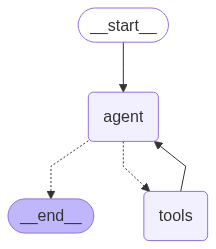

In [ ]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(llm, tools)
# system_prompt를 통해 시스템 프롬프트도 커스텀

agent

In [37]:
agent.invoke(
    {'messages':[HumanMessage('오늘 태어난 유명인 알려줘')]})

{'messages': [HumanMessage(content='오늘 태어난 유명인 알려줘', additional_kwargs={}, response_metadata={}, id='8a55e15b-1008-4f5d-a10a-eaa7f90f3218'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_6zgR8hoKB4d1CRWuQAjGsb4P', 'function': {'arguments': '{}', 'name': 'current_date'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 147, 'prompt_tokens': 318, 'total_tokens': 465, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-C7zb1OKynFmA4Vd3A5ecNOYnFghQ5', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--efe7da64-f263-45e8-8afc-9cbc6be0b75e-0', tool_calls=[{'name': 'current_date', 'args': {}, 'id': 'call_6zgR8hoKB4d1CRWuQAjGsb4P', 'type': 'tool_call'}],

자율 Agent는 산업의 다양한 분야에서 높은 활용성을 갖지만, 아래의 개선점을 고려해야 합니다.

- Context가 계속 늘어나기만 하는 구조이므로, 작업이 길어지면 성능이 저하됩니다.
- 당연한 툴 실행에도 매번 LLM을 다중 실행하므로, 토큰 소모가 큽니다.


여러 개의 에이전트가 서로 소통하도록 하는 멀티 에이전트 구조의 경우에는 해당 문제가 더욱 중요합니다.